# 🩺 BUSI Breast Ultrasound Image Classification Pipeline

**Task:** Multi-class classification of breast ultrasound images into three categories:
- **N** — Normal
- **B** — Benign
- **M** — Malignant

**Pipeline Overview:**
1. Data Loading & Parsing
2. Patient-Level Hold-out Split (80/20)
3. Data Augmentation (train only)
4. Deep Feature Extraction (MobileNetV2)
5. Class Balancing via SMOTE
6. Focal Loss Classifier Head
7. Training & Evaluation (Accuracy, F1, Confusion Matrix)

---
> **Dataset:** [BUSI Dataset](https://scholar.cu.edu.eg/?q=afahmy/pages/dataset) — W. Al-Dhabyani et al., 2020.  
> Place the dataset so that your directory structure looks like:
> ```
> Dataset_BUSI_with_GT/
>   benign/
>     benign (1).png
>     benign (1)_mask.png
>     ...
>   malignant/
>     malignant (1).png
>     malignant (1)_mask.png
>     ...
>   normal/
>     normal (1).png
>     normal (1)_mask.png
>     ...
> ```

## 📦 0. Install Dependencies

In [1]:
!pip install -q tensorflow scikit-learn imbalanced-learn matplotlib seaborn pillow numpy pandas tqdm

In [4]:
import os
import zipfile
import random
import numpy as np
import tensorflow as tf
from google.colab import files

def setup_kaggle_dataset():
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        print("Please upload your kaggle.json file.")
        uploaded = files.upload()
        os.makedirs('/root/.kaggle', exist_ok=True)
        for fn in uploaded.keys():
            os.rename(fn, '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 600)

    dataset_id = "aryashah2k/breast-ultrasound-images-dataset"
    if not os.path.exists('breast-ultrasound-images-dataset.zip'):
        print("Downloading dataset from Kaggle...")
        os.system(f'kaggle datasets download -d {dataset_id}')

    if not os.path.exists('Dataset_BUSI_with_GT'):
        print("Extracting data...")
        with zipfile.ZipFile('breast-ultrasound-images-dataset.zip', 'r') as zip_ref:
            zip_ref.extractall('.')
    print("✅ Dataset ready.")

## 🔧 1. Imports & Configuration

In [7]:
import re
import warnings
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

setup_kaggle_dataset()

# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Global Configuration ──────────────────────────────────────────────────────
CONFIG = {
    'data_dir'      : 'Dataset_BUSI_with_GT',
    'img_size'      : (224, 224),
    'batch_size'    : 32,
    'train_split'   : 0.80,
    'seed'          : SEED,
    'class_map'     : {'benign': 'B', 'malignant': 'M', 'normal': 'N'},
    'class_names'   : ['B', 'M', 'N'],
    # Focal Loss hyperparameters
    'focal_gamma'   : 2.0,
    'focal_alpha'   : 0.25,
    # Classifier head training
    'epochs'        : 40,
    'learning_rate' : 1e-3,
    'dropout_rate'  : 0.4,
}

print('✅ Imports complete. TensorFlow version:', tf.__version__)
print('   Config:', CONFIG)

Extracting data...
✅ Dataset ready.
✅ Imports complete. TensorFlow version: 2.19.0
   Config: {'data_dir': 'Dataset_BUSI_with_GT', 'img_size': (224, 224), 'batch_size': 32, 'train_split': 0.8, 'seed': 42, 'class_map': {'benign': 'B', 'malignant': 'M', 'normal': 'N'}, 'class_names': ['B', 'M', 'N'], 'focal_gamma': 2.0, 'focal_alpha': 0.25, 'epochs': 40, 'learning_rate': 0.001, 'dropout_rate': 0.4}


## 📂 2. Data Loading & Parsing

We scan the BUSI directory structure, **skip mask images** (`*_mask.png`), and build a flat list of `(filepath, class_label, patient_id)` tuples.

In [8]:
def parse_busi_dataset(data_dir: str, class_map: dict) -> pd.DataFrame:
    """
    Walk the BUSI directory structure and build a metadata DataFrame.

    Expected layout:
        data_dir/
            benign/benign (1).png, benign (1)_mask.png, ...
            malignant/malignant (1).png, ...
            normal/normal (1).png, ...

    Returns
    -------
    pd.DataFrame with columns: filepath, label, patient_id, class_folder
    """
    records = []
    data_path = Path(data_dir)

    for folder, short_label in class_map.items():
        folder_path = data_path / folder
        if not folder_path.exists():
            raise FileNotFoundError(
                f"Expected folder '{folder_path}' not found. "
                f"Please check CONFIG['data_dir']."
            )

        for fpath in sorted(folder_path.iterdir()):
            # Skip mask files and non-image files
            if '_mask' in fpath.stem:
                continue
            if fpath.suffix.lower() not in ('.png', '.jpg', '.jpeg', '.bmp'):
                continue

            # Extract numeric patient ID from filename, e.g. "benign (42)"
            match = re.search(r'\((\d+)\)', fpath.stem)
            patient_id = int(match.group(1)) if match else -1

            records.append({
                'filepath'    : str(fpath),
                'label'       : short_label,
                'patient_id'  : patient_id,
                'class_folder': folder,
            })

    df = pd.DataFrame(records)
    return df


# ─── Load metadata ─────────────────────────────────────────────────────────────
df_meta = parse_busi_dataset(CONFIG['data_dir'], CONFIG['class_map'])

print(f'Total images found (masks excluded): {len(df_meta)}')
print('\nClass distribution:')
print(df_meta['label'].value_counts().rename_axis('Class').reset_index(name='Count').to_string(index=False))
print('\nSample rows:')
df_meta.head()

Total images found (masks excluded): 780

Class distribution:
Class  Count
    B    437
    M    210
    N    133

Sample rows:


,filepath,label,patient_id,class_folder
0,Dataset_BUSI_with_GT/benign/benign (1).png,B,1,benign
1,Dataset_BUSI_with_GT/benign/benign (10).png,B,10,benign
2,Dataset_BUSI_with_GT/benign/benign (100).png,B,100,benign
3,Dataset_BUSI_with_GT/benign/benign (101).png,B,101,benign
4,Dataset_BUSI_with_GT/benign/benign (102).png,B,102,benign


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


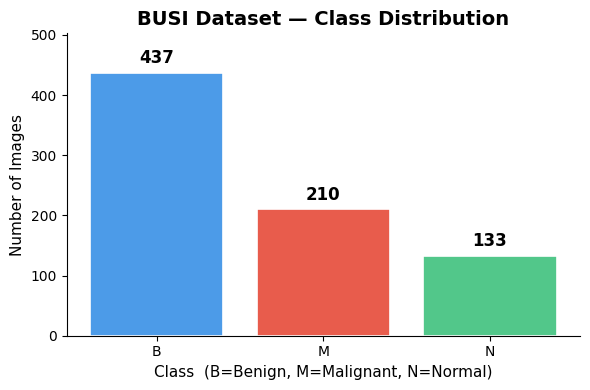

In [10]:
# ─── Visualise class distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_meta['label'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#4C9BE8', '#E85C4C', '#52C78A'], edgecolor='white', linewidth=1.2)
ax.bar_label(bars, padding=4, fontsize=12, fontweight='bold')
ax.set_title('BUSI Dataset — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Class  (B=Benign, M=Malignant, N=Normal)', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## 🔀 3. Patient-Level Hold-out Split

Patient IDs are **grouped per class folder** (since `benign (1)` and `malignant (1)` are different patients with the same numeric ID).  
We split the patients 80/20 *within each class* to maintain rough class proportions, then verify **zero overlap**.

In [11]:
def patient_holdout_split(
    df: pd.DataFrame,
    train_frac: float = 0.80,
    seed: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split images at the PATIENT level, stratified by class folder.

    A unique patient key is (class_folder, patient_id) — this avoids
    the collision between e.g. 'benign (1)' and 'malignant (1)'.

    Returns
    -------
    train_df, test_df  (no shared patients between them)
    """
    rng = np.random.default_rng(seed)

    train_indices, test_indices = [], []

    for folder in df['class_folder'].unique():
        sub = df[df['class_folder'] == folder]
        unique_patients = sub['patient_id'].unique()
        rng.shuffle(unique_patients)          # in-place shuffle

        n_train = max(1, int(np.floor(len(unique_patients) * train_frac)))
        train_pids = set(unique_patients[:n_train])
        test_pids  = set(unique_patients[n_train:])

        train_indices.extend(sub[sub['patient_id'].isin(train_pids)].index.tolist())
        test_indices.extend(sub[sub['patient_id'].isin(test_pids)].index.tolist())

    train_df = df.loc[train_indices].reset_index(drop=True)
    test_df  = df.loc[test_indices].reset_index(drop=True)
    return train_df, test_df


train_df, test_df = patient_holdout_split(
    df_meta,
    train_frac=CONFIG['train_split'],
    seed=CONFIG['seed']
)

# ─── Validation: zero patient overlap ──────────────────────────────────────────
def make_patient_key(df):
    return set(zip(df['class_folder'], df['patient_id']))

train_keys = make_patient_key(train_df)
test_keys  = make_patient_key(test_df)
overlap    = train_keys & test_keys

assert len(overlap) == 0, f'LEAKAGE DETECTED — {len(overlap)} patients appear in both splits!'
print('✅ Zero patient overlap confirmed between train and test sets.')

# ─── Reporting Output (copy to report) ─────────────────────────────────────────
print(f'\n>>> TRAINING SET   : {len(train_df):>4d} images')
print(f'>>> TESTING  SET   : {len(test_df):>4d} images')
print(f'>>> TOTAL          : {len(train_df) + len(test_df):>4d} images')

print('\nTraining class distribution:')
print(train_df['label'].value_counts().to_string())
print('\nTesting class distribution:')
print(test_df['label'].value_counts().to_string())

✅ Zero patient overlap confirmed between train and test sets.

>>> TRAINING SET   :  623 images
>>> TESTING  SET   :  157 images
>>> TOTAL          :  780 images

Training class distribution:
label
B    349
M    168
N    106

Testing class distribution:
label
B    88
M    42
N    27


## 🖼️ 4. Image Loading Utility

A vectorised loader that reads images from disk, converts to RGB, and resizes to 224×224.

In [12]:
def load_images(filepaths: list, img_size: tuple = (224, 224)) -> np.ndarray:
    """
    Load a list of image paths → float32 numpy array of shape (N, H, W, 3).
    Images are normalised to [0, 1].
    """
    images = []
    for fp in tqdm(filepaths, desc='Loading images', unit='img'):
        img = Image.open(fp).convert('RGB').resize(img_size, Image.BILINEAR)
        images.append(np.array(img, dtype=np.float32) / 255.0)
    return np.stack(images, axis=0)


print('Loading training images …')
X_train_raw = load_images(train_df['filepath'].tolist(), CONFIG['img_size'])
print('Loading test images …')
X_test_raw  = load_images(test_df['filepath'].tolist(),  CONFIG['img_size'])

# Encode labels
le = LabelEncoder()
le.fit(CONFIG['class_names'])

y_train = le.transform(train_df['label'].tolist())
y_test  = le.transform(test_df['label'].tolist())

print(f'\nX_train shape : {X_train_raw.shape}  |  y_train shape: {y_train.shape}')
print(f'X_test  shape : {X_test_raw.shape}  |  y_test  shape: {y_test.shape}')
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Loading training images …


Loading images: 100%|██████████| 623/623 [00:10<00:00, 61.39img/s]


Loading test images …


Loading images: 100%|██████████| 157/157 [00:01<00:00, 80.59img/s]



X_train shape : (623, 224, 224, 3)  |  y_train shape: (623,)
X_test  shape : (157, 224, 224, 3)  |  y_test  shape: (157,)
Label encoding: {np.str_('B'): np.int64(0), np.str_('M'): np.int64(1), np.str_('N'): np.int64(2)}


## 🔄 5. Data Augmentation (Training Only)

Augmentation is applied **only to training images** before feature extraction.  
Transforms used:
- Random horizontal flip  
- Random rotation ±15°  
- Zoom range 10%  
- Width / height shift 10%  

We use Keras `ImageDataGenerator` to augment in-memory.

Augmenting (×2): 100%|██████████| 623/623 [00:21<00:00, 28.86img/s]



Post-augmentation training set: 1869 images  (was 623)


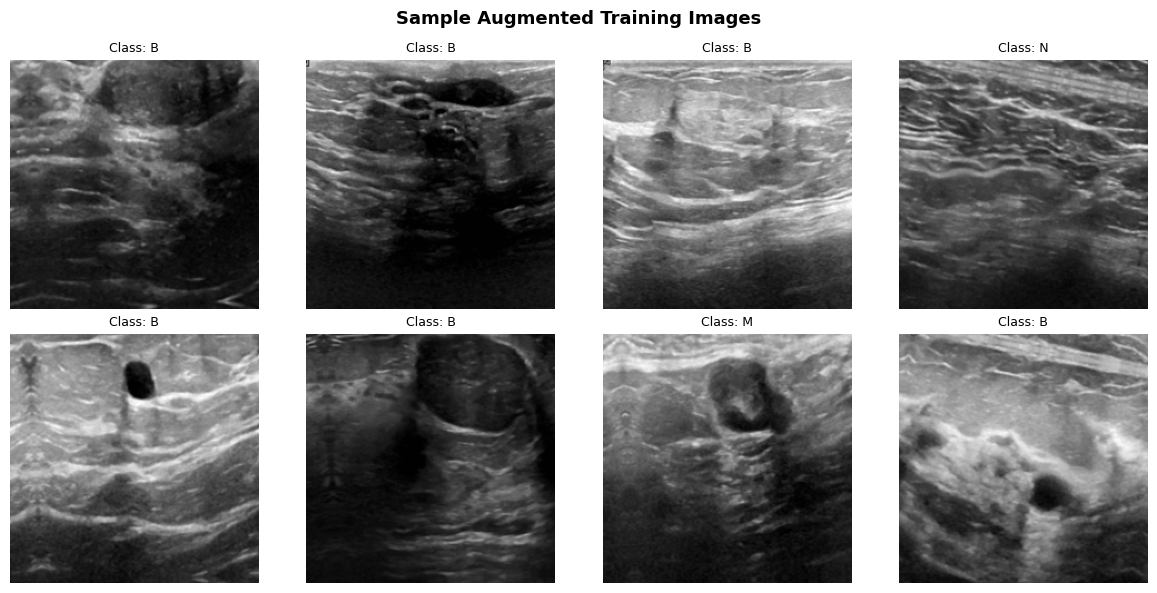

In [13]:
def augment_dataset(
    X: np.ndarray,
    y: np.ndarray,
    augment_factor: int = 2,
    seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    """
    Apply offline augmentation.

    Each original image generates `augment_factor` augmented copies.
    Returns the ORIGINAL images concatenated with the augmented ones.
    """
    datagen = ImageDataGenerator(
        horizontal_flip=True,
        rotation_range=15,
        zoom_range=0.10,
        width_shift_range=0.10,
        height_shift_range=0.10,
        fill_mode='reflect'
    )

    aug_imgs, aug_labels = [], []

    for img, label in tqdm(
        zip(X, y), total=len(X),
        desc=f'Augmenting (×{augment_factor})', unit='img'
    ):
        img_4d = img[np.newaxis, ...]  # (1, H, W, 3)
        gen = datagen.flow(img_4d, batch_size=1, seed=seed)
        for _ in range(augment_factor):
            aug_imgs.append(next(gen)[0])
            aug_labels.append(label)

    X_aug = np.concatenate([X, np.stack(aug_imgs)], axis=0)
    y_aug = np.concatenate([y, np.array(aug_labels)], axis=0)

    # Shuffle
    idx = np.random.default_rng(seed).permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]


X_train_aug, y_train_aug = augment_dataset(
    X_train_raw, y_train,
    augment_factor=2,
    seed=CONFIG['seed']
)

print(f'\nPost-augmentation training set: {X_train_aug.shape[0]} images  '
      f'(was {len(X_train_raw)})')

# ─── Sample augmented images ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train_aug[i])
    ax.set_title(f'Class: {le.inverse_transform([y_train_aug[i]])[0]}', fontsize=9)
    ax.axis('off')
fig.suptitle('Sample Augmented Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

## 🧠 6. Deep Feature Extraction — MobileNetV2

We use **MobileNetV2** pre-trained on ImageNet with the classification head removed (`include_top=False`, `pooling='avg'`).  
This produces a **1280-dimensional feature vector** per image.

Weights are frozen — we use the network purely as a feature extractor.

In [14]:
def build_feature_extractor(img_size: tuple = (224, 224)) -> Model:
    """
    MobileNetV2 as a frozen feature extractor.
    Output: (N, 1280) feature vectors.
    """
    base = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        pooling='avg',
        weights='imagenet'
    )
    base.trainable = False  # freeze all weights
    return base


def extract_features(
    model: Model,
    images: np.ndarray,
    batch_size: int = 32
) -> np.ndarray:
    """Run images through the feature extractor in batches."""
    # MobileNetV2 expects inputs in [-1, 1] via preprocess_input
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    imgs_scaled = preprocess_input(images * 255.0)   # undo [0,1] → [0,255] → preprocess
    feats = model.predict(imgs_scaled, batch_size=batch_size, verbose=1)
    return feats


feature_extractor = build_feature_extractor(CONFIG['img_size'])
feature_extractor.summary()

print('\n⏳ Extracting features from augmented training set …')
X_train_feats = extract_features(feature_extractor, X_train_aug, CONFIG['batch_size'])

print('\n⏳ Extracting features from test set …')
X_test_feats = extract_features(feature_extractor, X_test_raw, CONFIG['batch_size'])

print(f'\nTrain feature matrix : {X_train_feats.shape}')
print(f'Test  feature matrix : {X_test_feats.shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)


⏳ Extracting features from augmented training set …
59/59 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step

⏳ Extracting features from test set …
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

Train feature matrix : (1869, 1280)
Test  feature matrix : (157, 1280)


## ⚖️ 7. Class Balancing via SMOTE

SMOTE generates **synthetic** feature vectors for minority classes by interpolating between existing samples in the 1280-dimensional feature space.  
This avoids class imbalance bias without introducing visual artifacts.

Class distribution BEFORE SMOTE:
  B: 1047
  M: 504
  N: 318

Class distribution AFTER SMOTE:
  B: 1047
  M: 1047
  N: 1047

Balanced training set shape: (3141, 1280)


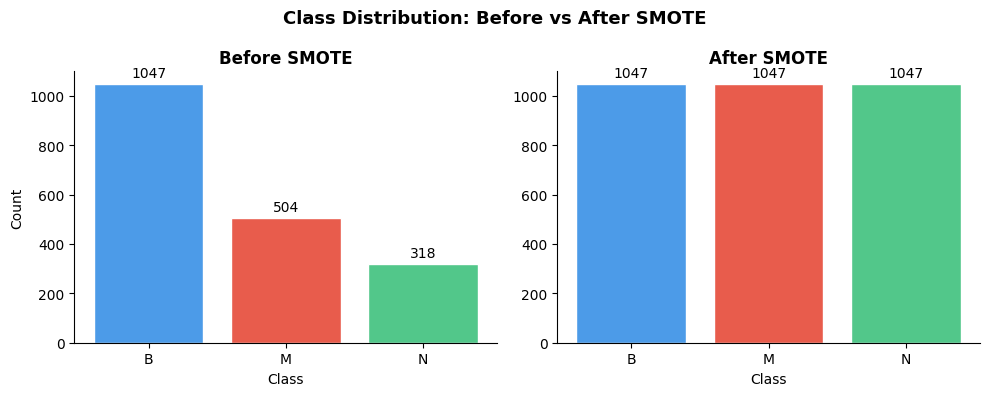

In [15]:
print('Class distribution BEFORE SMOTE:')
unique, counts = np.unique(y_train_aug, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique), counts):
    print(f'  {cls}: {cnt}')

smote = SMOTE(random_state=CONFIG['seed'], k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_feats, y_train_aug)

print('\nClass distribution AFTER SMOTE:')
unique2, counts2 = np.unique(y_train_balanced, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique2), counts2):
    print(f'  {cls}: {cnt}')
print(f'\nBalanced training set shape: {X_train_balanced.shape}')

# ─── Bar plot: before vs after ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
class_labels = le.inverse_transform(unique)
colors = ['#4C9BE8', '#E85C4C', '#52C78A']

ax1.bar(class_labels, counts, color=colors, edgecolor='white')
ax1.set_title('Before SMOTE', fontweight='bold')
ax1.set_ylabel('Count')
ax1.bar_label(ax1.containers[0], padding=3)

ax2.bar(le.inverse_transform(unique2), counts2, color=colors, edgecolor='white')
ax2.set_title('After SMOTE', fontweight='bold')
ax2.bar_label(ax2.containers[0], padding=3)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Class')

fig.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150)
plt.show()

## 📐 8. Focal Loss Implementation

Focal Loss re-weights the standard cross-entropy so that **easy, well-classified examples contribute less to the gradient**, forcing the model to focus on hard examples (like subtle malignant features).

$$FL(p_t) = -\alpha_t \; (1 - p_t)^{\gamma} \; \log(p_t)$$

- $\gamma$ (focusing parameter): higher values de-emphasise easy examples more strongly  
- $\alpha$ (class balance): down-weights the contribution of the majority class

In [16]:
class FocalLoss(keras.losses.Loss):
    """
    Multi-class Focal Loss.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameters
    ----------
    gamma : float
        Focusing parameter. gamma=0 reduces to standard cross-entropy.
    alpha : float
        Scalar weight applied to all classes uniformly.
        For per-class alpha, pass a list of length num_classes.
    """

    def __init__(self, gamma: float = 2.0, alpha: float = 0.25,
                 name: str = 'focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        """
        y_true : (batch,) integer class labels  OR  (batch, C) one-hot
        y_pred : (batch, C) softmax probabilities
        """
        # Convert to one-hot if needed
        num_classes = tf.shape(y_pred)[-1]
        y_true_oh = tf.one_hot(
            tf.cast(tf.reshape(y_true, [-1]), tf.int32),
            depth=num_classes
        )

        # Clip predictions for numerical stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # p_t = probability assigned to the true class
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)

        # Focal weight: (1 - p_t)^gamma
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        # Cross-entropy component
        ce = -tf.math.log(p_t)

        # Focal loss
        loss = self.alpha * focal_weight * ce
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


# Quick sanity check
fl = FocalLoss(gamma=2.0, alpha=0.25)
dummy_true = tf.constant([0, 1, 2])
dummy_pred = tf.constant([[0.9, 0.05, 0.05],
                           [0.1, 0.8,  0.1 ],
                           [0.1, 0.1,  0.8 ]])
print(f'Focal Loss (sanity check, low loss expected): {fl(dummy_true, dummy_pred).numpy():.4f}')

dummy_pred_bad = tf.constant([[0.1, 0.5, 0.4],
                               [0.4, 0.3, 0.3],
                               [0.4, 0.4, 0.2]])
print(f'Focal Loss (sanity check, higher loss expected): {fl(dummy_true, dummy_pred_bad).numpy():.4f}')

Focal Loss (sanity check, low loss expected): 0.0016
Focal Loss (sanity check, higher loss expected): 0.2904


## 🏗️ 9. Classifier Head Architecture

A lightweight fully-connected network that takes 1280-dim feature vectors and outputs 3-class probabilities.

In [17]:
def build_classifier(
    input_dim: int,
    num_classes: int,
    dropout_rate: float = 0.4,
    learning_rate: float = 1e-3,
    gamma: float = 2.0,
    alpha: float = 0.25
) -> Model:
    """
    Fully-connected classifier head with BatchNorm and Dropout.

    Architecture
    ------------
    Input(1280)  →  Dense(512, ReLU) → BN → Dropout
                 →  Dense(256, ReLU) → BN → Dropout
                 →  Dense(128, ReLU) → BN → Dropout
                 →  Dense(num_classes, Softmax)
    """
    inputs = keras.Input(shape=(input_dim,), name='feature_input')

    x = layers.Dense(512, name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(dropout_rate, name='drop_1')(x)

    x = layers.Dense(256, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(dropout_rate, name='drop_2')(x)

    x = layers.Dense(128, name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(dropout_rate / 2, name='drop_3')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs, outputs, name='BUSI_Classifier')

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
            weight_decay=1e-4          # L2 regularisation via Adam weight decay
        ),
        loss=FocalLoss(gamma=gamma, alpha=alpha),
        metrics=['accuracy']
    )
    return model


num_classes = len(le.classes_)
classifier = build_classifier(
    input_dim=X_train_balanced.shape[1],
    num_classes=num_classes,
    dropout_rate=CONFIG['dropout_rate'],
    learning_rate=CONFIG['learning_rate'],
    gamma=CONFIG['focal_gamma'],
    alpha=CONFIG['focal_alpha']
)
classifier.summary()

Model: "BUSI_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,067 (3.14 MB)

 Trainable params: 822,275 (3.14 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 🏋️ 10. Training

In [18]:
# ─── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_classifier.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    ),
]

# ─── Train ─────────────────────────────────────────────────────────────────────
history = classifier.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training complete.')

Epoch 1/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6928 - loss: 0.0952 - val_accuracy: 0.9597 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 2/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8336 - loss: 0.0413 - val_accuracy: 0.9682 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8898 - loss: 0.0264 - val_accuracy: 0.9894 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 4/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9157 - loss: 0.0198 - val_accuracy: 1.0000 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 5/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9543 - loss: 0.0110 - val_accuracy: 0.9936 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9592 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 1.1256e-04 - learning_rate: 0.0010
Epoch 7/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9629 - loss: 0.0083 - val

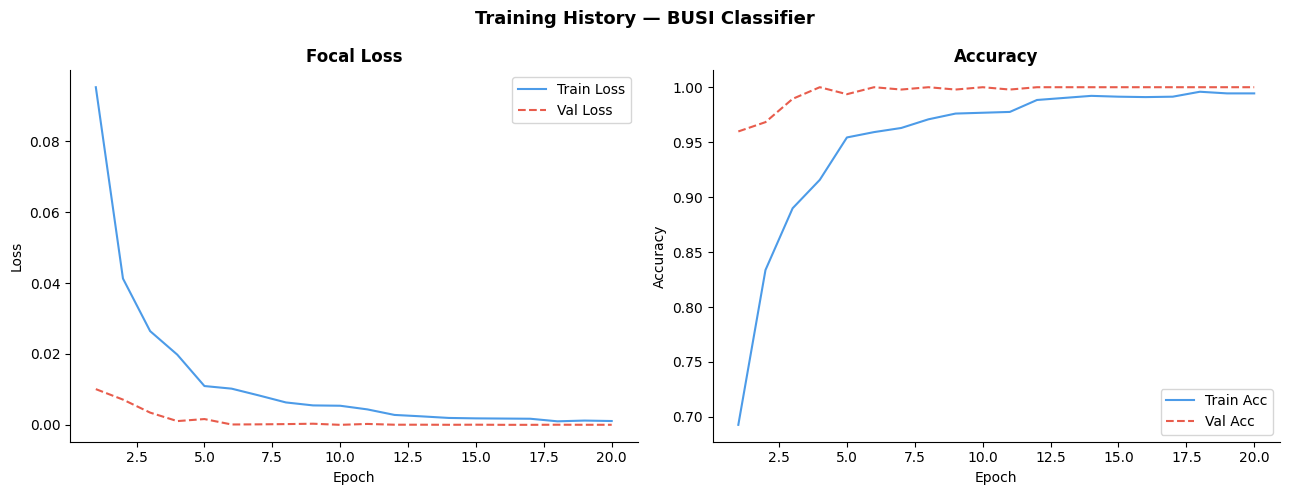

In [19]:
# ─── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_ran = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_ran, history.history['loss'],     label='Train Loss', color='#4C9BE8')
ax1.plot(epochs_ran, history.history['val_loss'], label='Val Loss',   color='#E85C4C', linestyle='--')
ax1.set_title('Focal Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(epochs_ran, history.history['accuracy'],     label='Train Acc', color='#4C9BE8')
ax2.plot(epochs_ran, history.history['val_accuracy'], label='Val Acc',   color='#E85C4C', linestyle='--')
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Training History — BUSI Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## 📊 11. Evaluation on Held-Out Test Set

In [20]:
# ─── Predict ───────────────────────────────────────────────────────────────────
y_pred_proba = classifier.predict(X_test_feats, batch_size=CONFIG['batch_size'], verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# ─── Overall Accuracy ──────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f'\n{'='*50}')
print(f'  OVERALL TEST ACCURACY : {acc * 100:.2f}%')
print(f'{'='*50}\n')

# ─── Per-class Report ──────────────────────────────────────────────────────────
target_names = le.classes_   # ['B', 'M', 'N']
report = classification_report(y_test, y_pred, target_names=target_names, digits=4)
print('Classification Report (B=Benign, M=Malignant, N=Normal):')
print(report)


  OVERALL TEST ACCURACY : 80.89%

Classification Report (B=Benign, M=Malignant, N=Normal):
              precision    recall  f1-score   support

           B     0.8506    0.8409    0.8457        88
           M     0.8529    0.6905    0.7632        42
           N     0.6667    0.8889    0.7619        27

    accuracy                         0.8089       157
   macro avg     0.7901    0.8068    0.7903       157
weighted avg     0.8196    0.8089    0.8092       157



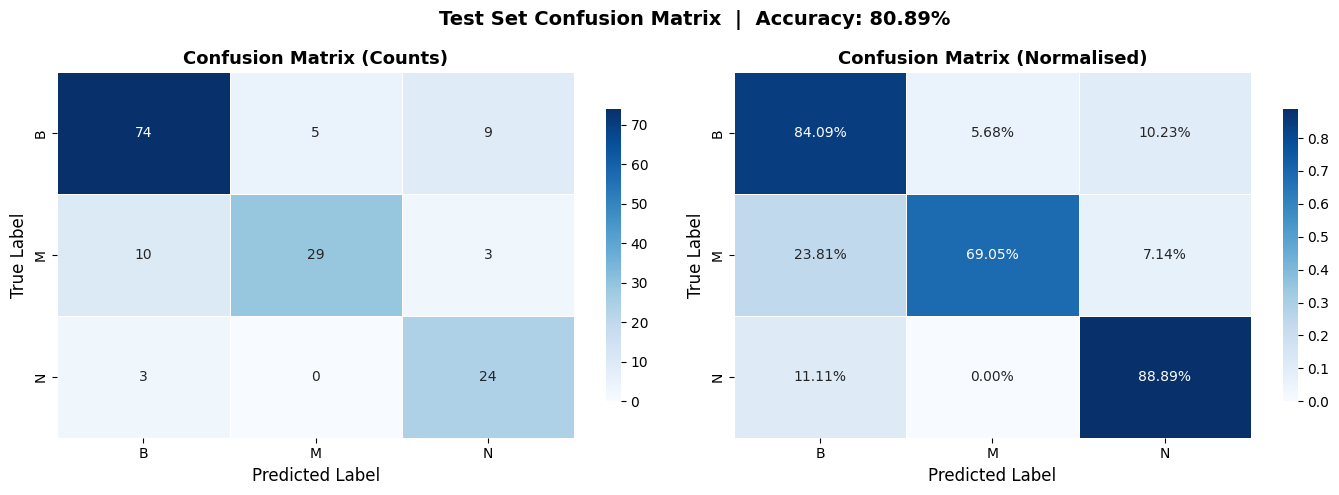


Per-class raw counts:
Predicted   B   M   N
True                 
B          74   5   9
M          10  29   3
N           3   0  24


In [21]:
# ─── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalised)']
):
    sns.heatmap(
        data,
        annot=True, fmt=fmt,
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle(
    f'Test Set Confusion Matrix  |  Accuracy: {acc*100:.2f}%',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print('\nPer-class raw counts:')
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df.index.name = 'True'
cm_df.columns.name = 'Predicted'
print(cm_df)


Detailed per-class metrics:
Class  Precision   Recall  F1-Score  Support
    B   0.850575 0.840909  0.845714       88
    M   0.852941 0.690476  0.763158       42
    N   0.666667 0.888889  0.761905       27


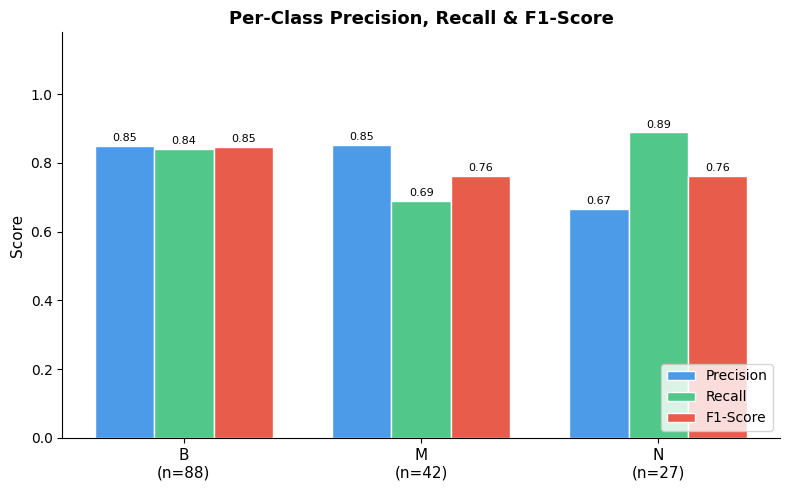

In [22]:
# ─── Per-class Precision / Recall / F1 bar chart ──────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=list(range(num_classes))
)

metrics_df = pd.DataFrame({
    'Class'    : target_names,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1,
    'Support'  : support.astype(int)
})
print('\nDetailed per-class metrics:')
print(metrics_df.to_string(index=False))

x = np.arange(num_classes)
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))

bars_p = ax.bar(x - width, precision, width, label='Precision', color='#4C9BE8', edgecolor='white')
bars_r = ax.bar(x,         recall,    width, label='Recall',    color='#52C78A', edgecolor='white')
bars_f = ax.bar(x + width, f1,        width, label='F1-Score',  color='#E85C4C', edgecolor='white')

for bars in (bars_p, bars_r, bars_f):
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(n={s})' for c, s in zip(target_names, support)], fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-Class Precision, Recall & F1-Score', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150)
plt.show()

## 📈 12. ROC Curves (One-vs-Rest)

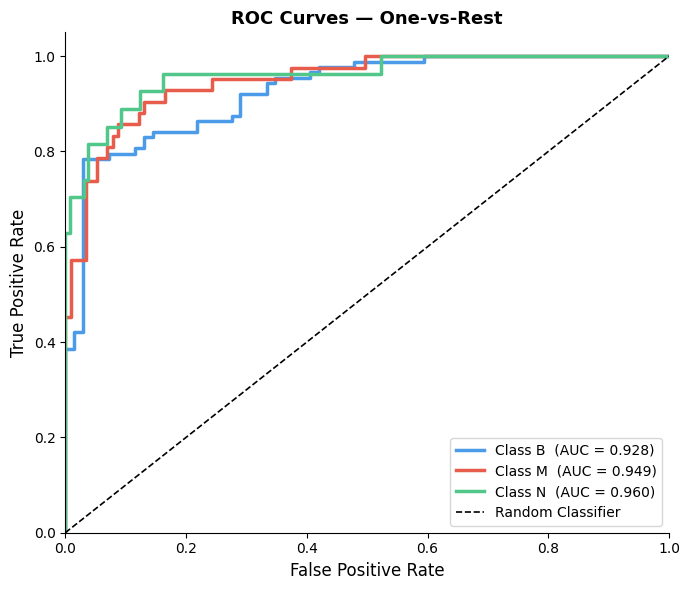

In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(7, 6))
palette = ['#4C9BE8', '#E85C4C', '#52C78A']

for i, (cls, color) in enumerate(zip(target_names, palette)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'Class {cls}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

## 🔍 13. Qualitative Inspection — Correct & Incorrect Predictions

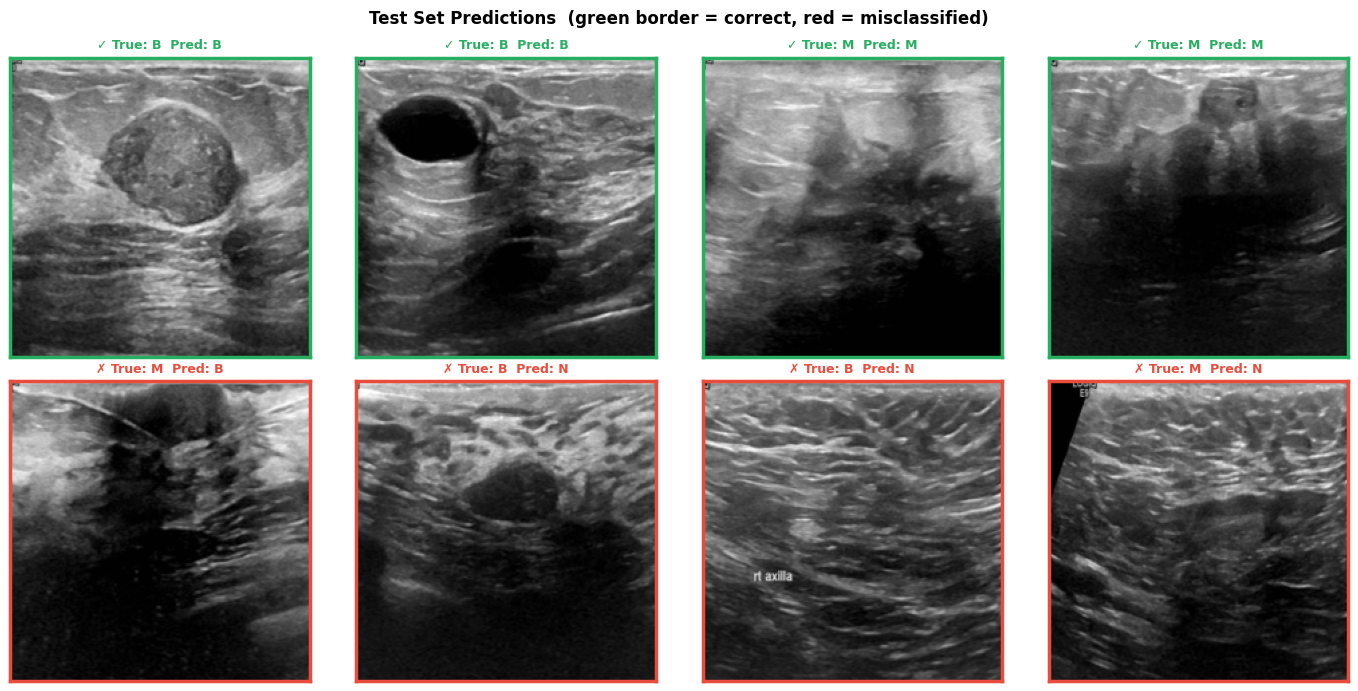

In [24]:
def show_prediction_grid(
    X: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    label_encoder,
    n_correct: int = 4,
    n_wrong: int = 4
):
    """Show a grid of correct and incorrect test-set predictions."""
    correct_idx = np.where(y_true == y_pred)[0]
    wrong_idx   = np.where(y_true != y_pred)[0]

    rng = np.random.default_rng(CONFIG['seed'])
    sel_correct = rng.choice(correct_idx, size=min(n_correct, len(correct_idx)), replace=False)
    sel_wrong   = rng.choice(wrong_idx,   size=min(n_wrong,   len(wrong_idx)),   replace=False)

    all_idx  = np.concatenate([sel_correct, sel_wrong])
    n_cols   = 4
    n_rows   = int(np.ceil(len(all_idx) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
    axes = axes.flatten()

    for ax_idx, img_idx in enumerate(all_idx):
        ax = axes[ax_idx]
        ax.imshow(X[img_idx])
        true_lbl = label_encoder.inverse_transform([y_true[img_idx]])[0]
        pred_lbl = label_encoder.inverse_transform([y_pred[img_idx]])[0]
        correct  = y_true[img_idx] == y_pred[img_idx]
        color    = '#27AE60' if correct else '#E74C3C'
        symbol   = '✓' if correct else '✗'
        ax.set_title(
            f'{symbol} True: {true_lbl}  Pred: {pred_lbl}',
            color=color, fontsize=9, fontweight='bold'
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(all_idx):]:
        ax.axis('off')

    fig.suptitle(
        'Test Set Predictions  (green border = correct, red = misclassified)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('prediction_grid.png', dpi=150)
    plt.show()


show_prediction_grid(X_test_raw, y_test, y_pred, le, n_correct=4, n_wrong=4)

## 📋 14. Final Summary Report

In [25]:
print('=' * 60)
print('       BUSI CLASSIFICATION PIPELINE — FINAL REPORT')
print('=' * 60)

print(f'\n[1] Dataset Split')
print(f'    Training images  : {len(train_df)}')
print(f'    Testing  images  : {len(test_df)}')
print(f'    Patient overlap  : ZERO (verified)')

print(f'\n[2] After Augmentation (×2)')
print(f'    Training images  : {len(X_train_aug)}')

print(f'\n[3] After SMOTE')
unique_s, cnt_s = np.unique(y_train_balanced, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique_s), cnt_s):
    print(f'    Class {cls}          : {cnt}')

print(f'\n[4] Feature Extractor  : MobileNetV2 (ImageNet, frozen)')
print(f'    Feature dim        : {X_train_balanced.shape[1]}')

print(f'\n[5] Loss Function      : Focal Loss (gamma={CONFIG["focal_gamma"]}, alpha={CONFIG["focal_alpha"]})')

print(f'\n[6] Test Set Results')
print(f'    Overall Accuracy   : {acc * 100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))
print('=' * 60)

       BUSI CLASSIFICATION PIPELINE — FINAL REPORT

[1] Dataset Split
    Training images  : 623
    Testing  images  : 157
    Patient overlap  : ZERO (verified)

[2] After Augmentation (×2)
    Training images  : 1869

[3] After SMOTE
    Class B          : 1047
    Class M          : 1047
    Class N          : 1047

[4] Feature Extractor  : MobileNetV2 (ImageNet, frozen)
    Feature dim        : 1280

[5] Loss Function      : Focal Loss (gamma=2.0, alpha=0.25)

[6] Test Set Results
    Overall Accuracy   : 80.89%

              precision    recall  f1-score   support

           B     0.8506    0.8409    0.8457        88
           M     0.8529    0.6905    0.7632        42
           N     0.6667    0.8889    0.7619        27

    accuracy                         0.8089       157
   macro avg     0.7901    0.8068    0.7903       157
weighted avg     0.8196    0.8089    0.8092       157



## 💾 15. Save Model & Artefacts

In [26]:
# Save the trained classifier head
classifier.save('busi_classifier_head.keras')
print('✅ Classifier head saved → busi_classifier_head.keras')

# Save label encoder classes
np.save('label_classes.npy', le.classes_)
print('✅ Label classes saved  → label_classes.npy')

# Save feature matrices (optional — useful for ablation studies)
np.save('X_test_feats.npy',  X_test_feats)
np.save('y_test.npy',        y_test)
print('✅ Test features saved  → X_test_feats.npy, y_test.npy')

print('\nAll output figures:')
figures = [
    'class_distribution.png',
    'augmented_samples.png',
    'smote_comparison.png',
    'training_history.png',
    'confusion_matrix.png',
    'per_class_metrics.png',
    'roc_curves.png',
    'prediction_grid.png'
]
for f in figures:
    exists = '✅' if Path(f).exists() else '⚠️  (will exist after running all cells)'
    print(f'  {exists}  {f}')

✅ Classifier head saved → busi_classifier_head.keras
✅ Label classes saved  → label_classes.npy
✅ Test features saved  → X_test_feats.npy, y_test.npy

All output figures:
  ✅  class_distribution.png
  ✅  augmented_samples.png
  ✅  smote_comparison.png
  ✅  training_history.png
  ✅  confusion_matrix.png
  ✅  per_class_metrics.png
  ✅  roc_curves.png
  ✅  prediction_grid.png


## 🔮 16. (Bonus) Single-Image Inference Utility

A ready-to-use function you can call from any script or Streamlit app.

In [27]:
def predict_single_image(
    image_path: str,
    feature_extractor: Model,
    classifier: Model,
    label_encoder: LabelEncoder,
    img_size: tuple = (224, 224)
) -> dict:
    """
    End-to-end inference on a single ultrasound image.

    Returns
    -------
    dict with keys: predicted_class, confidence, all_probabilities
    """
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

    # Load & preprocess
    img = Image.open(image_path).convert('RGB').resize(img_size, Image.BILINEAR)
    img_arr = np.array(img, dtype=np.float32) / 255.0   # [0, 1]
    img_batch = img_arr[np.newaxis, ...]                 # (1, H, W, 3)

    # Feature extraction
    img_scaled = mobilenet_preprocess(img_batch * 255.0)
    feats = feature_extractor.predict(img_scaled, verbose=0)  # (1, 1280)

    # Classification
    proba = classifier.predict(feats, verbose=0)[0]     # (num_classes,)
    pred_idx = int(np.argmax(proba))

    return {
        'predicted_class'   : label_encoder.inverse_transform([pred_idx])[0],
        'confidence'        : float(proba[pred_idx]),
        'all_probabilities' : dict(zip(label_encoder.classes_, proba.tolist()))
    }


# ─── Demo (runs on a random test image) ────────────────────────────────────────
sample_path = test_df['filepath'].iloc[0]
result = predict_single_image(
    sample_path, feature_extractor, classifier, le, CONFIG['img_size']
)

print(f'Image  : {Path(sample_path).name}')
print(f'True label    : {test_df["label"].iloc[0]}')
print(f'Predicted     : {result["predicted_class"]}  (confidence: {result["confidence"]*100:.1f}%)')
print(f'All probs     : { {k: f"{v*100:.1f}%" for k, v in result["all_probabilities"].items()} }')

Image  : benign (10).png
True label    : B
Predicted     : B  (confidence: 98.8%)
All probs     : {np.str_('B'): '98.8%', np.str_('M'): '0.2%', np.str_('N'): '1.0%'}


---

## ✅ Pipeline Complete

| Step | Component | Detail |
|------|-----------|--------|
| 1 | Data Parsing | BUSI 3-class, masks excluded |
| 2 | Patient Split | 80/20, zero-overlap guaranteed |
| 3 | Augmentation | Flip + Rot±15° + Zoom, train only |
| 4 | Feature Extraction | MobileNetV2 ImageNet (frozen) → 1280-dim |
| 5 | Class Balancing | SMOTE on feature vectors |
| 6 | Loss | Focal Loss (γ=2, α=0.25) |
| 7 | Classifier | FC 512→256→128→3 + BN + Dropout |
| 8 | Evaluation | Accuracy, Precision, Recall, F1, CM, ROC |

**Reference:** W. Al-Dhabyani et al., *"Dataset of breast ultrasound images"*, Data in Brief, 2020. [DOI: 10.1016/j.dib.2019.104863](https://doi.org/10.1016/j.dib.2019.104863)